## 1. Setup

In [2]:
import random
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    balanced_accuracy_score,
    accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
)

DATA_DIR = Path("/kaggle/input/datasets/tazana/deeplearningfinal-data/processed")
RESULTS_DIR = Path("/kaggle/working")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

Device: cuda


### Semillas

In [3]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

### Cargar y limpiar datos

In [4]:
X = pd.read_csv(DATA_DIR / "X_multimodal.csv")
y = pd.read_csv(DATA_DIR / "y_target_any_semen_abnormality.csv")
y = y.iloc[:, 0].astype(int)

print("X original:", X.shape)
print("y:", y.shape)

# Limpiar columnas duplicadas _x / _y
cols_to_drop = []
rename_map = {}

for col in X.columns:
    if col.endswith("_x"):
        base = col[:-2]
        pair = base + "_y"

        if pair in X.columns:
            x_values = pd.to_numeric(
                X[col].astype(str).str.replace(",", ".", regex=False),
                errors="coerce"
            )
            y_values = pd.to_numeric(
                X[pair].astype(str).str.replace(",", ".", regex=False),
                errors="coerce"
            )

            if np.allclose(x_values, y_values, equal_nan=True):
                cols_to_drop.append(pair)
                rename_map[col] = base
            else:
                print(f"Advertencia: {col} y {pair} no son iguales.")

X = X.drop(columns=cols_to_drop)
X = X.rename(columns=rename_map)

# Convertir todo X a numérico
for col in X.columns:
    if X[col].dtype == "object":
        X[col] = (
            X[col]
            .astype(str)
            .str.strip()
            .str.replace(",", ".", regex=False)
        )

    X[col] = pd.to_numeric(X[col], errors="coerce")

# Quitar identificadores o columnas no válidas como variables predictoras
forbidden_cols = [
    "id",
    "video",
    "video_filename",
    "video_key",
]

forbidden_cols = [c for c in forbidden_cols if c in X.columns]

print("Columnas excluidas:", forbidden_cols)

X = X.drop(columns=forbidden_cols)

print("X limpio:", X.shape)
print("y:", y.shape)

print("\nTipos:")
print(X.dtypes.value_counts())

print("\nColumnas no numéricas:")
print(X.select_dtypes(exclude=["number"]).columns.tolist())

print("\nMissing values:")
display(
    X.isna()
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

print("\nTarget:")
print(y.value_counts())
print(y.value_counts(normalize=True))

X original: (85, 76)
y: (85,)
Columnas excluidas: ['video', 'video_key']
X limpio: (85, 70)
y: (85,)

Tipos:
float64    65
int64       5
Name: count, dtype: int64

Columnas no numéricas:
[]

Missing values:


participant_abstinence_timedays                    0.011765
participant_body_mass_index_kg_m2                  0.000000
participant_age_years                              0.000000
serum_serum_c14_0_myristic_acid                    0.000000
serum_serum_c16_0_palmitic_acid                    0.000000
serum_serum_c16_1_palmitoleic_acid                 0.000000
serum_serum_c18_0_stearic_acid                     0.000000
serum_serum_c18_1_n_9_oleic_acid                   0.000000
serum_serum_total_c18_1                            0.000000
serum_serum_c18_2_n_6_linoleic_acid_la             0.000000
serum_serum_c18_3_n_6_gamma_linoleic_acid_gla      0.000000
serum_serum_c20_1_n_9                              0.000000
serum_serum_c20_2_n_6                              0.000000
serum_serum_c20_3_n_6                              0.000000
serum_serum_c20_4_n_6                              0.000000
serum_serum_c20_5_n_3_eicosapentaenoic_acid_epa    0.000000
serum_serum_c22_5_n_3_docosapentaenoic_a


Target:
target_any_semen_abnormality
1    59
0    26
Name: count, dtype: int64
target_any_semen_abnormality
1    0.694118
0    0.305882
Name: proportion, dtype: float64


## 2. Separar features clínicas y visuales

In [5]:
clinical_cols = [
    c for c in X.columns
    if not c.startswith("video_")
]

video_cols = [
    c for c in X.columns
    if c.startswith("video_")
]

print("Clinical features:", len(clinical_cols))
print("Video features:", len(video_cols))
print("Total features:", len(clinical_cols) + len(video_cols))

Clinical features: 49
Video features: 21
Total features: 70


## 3. Dataset PyTorch

In [6]:
class MultimodalTabularDataset(Dataset):
    def __init__(self, X_clinical, X_video, y):
        self.X_clinical = torch.tensor(X_clinical, dtype=torch.float32)
        self.X_video = torch.tensor(X_video, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return {
            "clinical": self.X_clinical[idx],
            "video": self.X_video[idx],
            "target": self.y[idx],
        }

<h2>4. Modelo MLP Multimodal</h2>

El modelo está compuesto por dos ramas de entrada:

<pre>
 Clinical Features ──┐
                     ├── Fusion MLP ─── Output (Sigmoid / Logit)
 Video Features ─────┘
</pre>

In [7]:
class MultimodalMLP(nn.Module):
    def __init__(
        self,
        clinical_dim: int,
        video_dim: int,
        clinical_hidden: int = 32,
        video_hidden: int = 16,
        fusion_hidden: int = 32,
        dropout: float = 0.30,
    ):
        super().__init__()

        self.clinical_branch = nn.Sequential(
            nn.Linear(clinical_dim, clinical_hidden),
            nn.BatchNorm1d(clinical_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.video_branch = nn.Sequential(
            nn.Linear(video_dim, video_hidden),
            nn.BatchNorm1d(video_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.classifier = nn.Sequential(
            nn.Linear(clinical_hidden + video_hidden, fusion_hidden),
            nn.BatchNorm1d(fusion_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_hidden, 1),
        )

    def forward(self, x_clinical, x_video):
        clinical_repr = self.clinical_branch(x_clinical)
        video_repr = self.video_branch(x_video)

        fused = torch.cat([clinical_repr, video_repr], dim=1)
        logits = self.classifier(fused)

        return logits

## 5. Métricas

In [9]:
def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "average_precision": average_precision_score(y_true, y_prob),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
    }

    try:
        metrics["roc_auc"] = roc_auc_score(y_true, y_prob)
    except ValueError:
        metrics["roc_auc"] = np.nan

    return metrics

## 6. Entrenamiento con early stopping

In [15]:
def train_one_fold(
    Xc_train,
    Xv_train,
    y_train,
    Xc_val,
    Xv_val,
    y_val,
    clinical_dim,
    video_dim,
    seed,
    max_epochs=300,
    batch_size=16,
    learning_rate=1e-3,
    weight_decay=1e-3,
    patience=30,
):
    set_seed(seed)

    train_dataset = MultimodalTabularDataset(Xc_train, Xv_train, y_train)
    val_dataset = MultimodalTabularDataset(Xc_val, Xv_val, y_val)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        drop_last=False,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
    )

    model = MultimodalMLP(
        clinical_dim=clinical_dim,
        video_dim=video_dim,
    ).to(DEVICE)

    n_pos = np.sum(y_train == 1)
    n_neg = np.sum(y_train == 0)

    pos_weight_value = n_neg / max(n_pos, 1)
    pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32).to(DEVICE)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    best_val_loss = np.inf
    best_state_dict = None
    epochs_without_improvement = 0

    history = []

    for epoch in range(max_epochs):
        model.train()

        for batch in train_loader:
            x_clinical = batch["clinical"].to(DEVICE)
            x_video = batch["video"].to(DEVICE)
            target = batch["target"].to(DEVICE)

            optimizer.zero_grad()

            logits = model(x_clinical, x_video)
            loss = criterion(logits, target)

            loss.backward()
            optimizer.step()

        # Evaluar al final de cada época
        train_metrics = evaluate_loader(model, train_loader, criterion)
        val_metrics = evaluate_loader(model, val_loader, criterion)

        history.append({
            "epoch": epoch,

            "train_loss": train_metrics["loss"],
            "val_loss": val_metrics["loss"],

            "train_accuracy": train_metrics["accuracy"],
            "val_accuracy": val_metrics["accuracy"],

            "train_balanced_accuracy": train_metrics["balanced_accuracy"],
            "val_balanced_accuracy": val_metrics["balanced_accuracy"],

            "train_f1": train_metrics["f1"],
            "val_f1": val_metrics["f1"],
        })

        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            best_state_dict = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    history_df = pd.DataFrame(history)

    return model, history_df

## 7. Predicción

In [16]:
def predict_proba(model, X_clinical, X_video, batch_size=64):
    dummy_y = np.zeros(len(X_clinical))

    dataset = MultimodalTabularDataset(
        X_clinical,
        X_video,
        dummy_y,
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
    )

    model.eval()
    probs = []

    with torch.no_grad():
        for batch in loader:
            x_clinical = batch["clinical"].to(DEVICE)
            x_video = batch["video"].to(DEVICE)

            logits = model(x_clinical, x_video)
            batch_probs = torch.sigmoid(logits).cpu().numpy().ravel()

            probs.extend(batch_probs)

    return np.array(probs)

## 8. Repeated cross-validation del MLP
Este bloque evalúa el MLP con la misma lógica del notebook 04: varias semillas y 5 folds estratificados.

In [17]:
def evaluate_loader(model, loader, criterion):
    model.eval()

    losses = []
    all_probs = []
    all_targets = []

    with torch.no_grad():
        for batch in loader:
            x_clinical = batch["clinical"].to(DEVICE)
            x_video = batch["video"].to(DEVICE)
            target = batch["target"].to(DEVICE)

            logits = model(x_clinical, x_video)
            loss = criterion(logits, target)

            probs = torch.sigmoid(logits).cpu().numpy().ravel()
            targets = target.cpu().numpy().ravel()

            losses.append(loss.item())
            all_probs.extend(probs)
            all_targets.extend(targets)

    y_true = np.array(all_targets).astype(int)
    y_prob = np.array(all_probs)
    y_pred = (y_prob >= 0.5).astype(int)

    metrics = {
        "loss": float(np.mean(losses)),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

    return metrics

In [18]:
X_clinical_all = X[clinical_cols].copy()
X_video_all = X[video_cols].copy()
y_all = y.values

seeds = [0, 1, 2, 3, 4, 42, 123, 2024, 2025, 2026]

all_fold_results = []
all_histories = []

for seed in seeds:
    outer_cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed,
    )

    for fold_idx, (trainval_idx, test_idx) in enumerate(
        outer_cv.split(X, y_all)
    ):
        print(f"Seed={seed} | Fold={fold_idx}")

        y_trainval = y_all[trainval_idx]
        y_test = y_all[test_idx]

        train_idx, val_idx = train_test_split(
            trainval_idx,
            test_size=0.20,
            stratify=y_trainval,
            random_state=seed + fold_idx,
        )

        y_train = y_all[train_idx]
        y_val = y_all[val_idx]

        Xc_train_raw = X_clinical_all.iloc[train_idx]
        Xc_val_raw = X_clinical_all.iloc[val_idx]
        Xc_test_raw = X_clinical_all.iloc[test_idx]

        Xv_train_raw = X_video_all.iloc[train_idx]
        Xv_val_raw = X_video_all.iloc[val_idx]
        Xv_test_raw = X_video_all.iloc[test_idx]

        clinical_imputer = SimpleImputer(strategy="median")
        video_imputer = SimpleImputer(strategy="median")

        clinical_scaler = StandardScaler()
        video_scaler = StandardScaler()

        Xc_train = clinical_imputer.fit_transform(Xc_train_raw)
        Xc_val = clinical_imputer.transform(Xc_val_raw)
        Xc_test = clinical_imputer.transform(Xc_test_raw)

        Xv_train = video_imputer.fit_transform(Xv_train_raw)
        Xv_val = video_imputer.transform(Xv_val_raw)
        Xv_test = video_imputer.transform(Xv_test_raw)

        Xc_train = clinical_scaler.fit_transform(Xc_train)
        Xc_val = clinical_scaler.transform(Xc_val)
        Xc_test = clinical_scaler.transform(Xc_test)

        Xv_train = video_scaler.fit_transform(Xv_train)
        Xv_val = video_scaler.transform(Xv_val)
        Xv_test = video_scaler.transform(Xv_test)

        model, history_df = train_one_fold(
            Xc_train=Xc_train,
            Xv_train=Xv_train,
            y_train=y_train,
            Xc_val=Xc_val,
            Xv_val=Xv_val,
            y_val=y_val,
            clinical_dim=Xc_train.shape[1],
            video_dim=Xv_train.shape[1],
            seed=seed + fold_idx,
        )

        y_prob = predict_proba(
            model,
            X_clinical=Xc_test,
            X_video=Xv_test,
        )

        fold_metrics = compute_metrics(y_test, y_prob)

        row = {
            "seed": seed,
            "fold": fold_idx,
            "model": "pytorch_multimodal_mlp",
            "feature_set": "multimodal",
            **fold_metrics,
        }

        all_fold_results.append(row)

        history_df["seed"] = seed
        history_df["fold"] = fold_idx
        all_histories.append(history_df)

mlp_results_df = pd.DataFrame(all_fold_results)
mlp_history_df = pd.concat(all_histories, ignore_index=True)

display(mlp_results_df.head())

Seed=0 | Fold=0
Seed=0 | Fold=1
Seed=0 | Fold=2
Seed=0 | Fold=3
Seed=0 | Fold=4
Seed=1 | Fold=0
Seed=1 | Fold=1
Seed=1 | Fold=2
Seed=1 | Fold=3
Seed=1 | Fold=4
Seed=2 | Fold=0
Seed=2 | Fold=1
Seed=2 | Fold=2
Seed=2 | Fold=3
Seed=2 | Fold=4
Seed=3 | Fold=0
Seed=3 | Fold=1
Seed=3 | Fold=2
Seed=3 | Fold=3
Seed=3 | Fold=4
Seed=4 | Fold=0
Seed=4 | Fold=1
Seed=4 | Fold=2
Seed=4 | Fold=3
Seed=4 | Fold=4
Seed=42 | Fold=0
Seed=42 | Fold=1
Seed=42 | Fold=2
Seed=42 | Fold=3
Seed=42 | Fold=4
Seed=123 | Fold=0
Seed=123 | Fold=1
Seed=123 | Fold=2
Seed=123 | Fold=3
Seed=123 | Fold=4
Seed=2024 | Fold=0
Seed=2024 | Fold=1
Seed=2024 | Fold=2
Seed=2024 | Fold=3
Seed=2024 | Fold=4
Seed=2025 | Fold=0
Seed=2025 | Fold=1
Seed=2025 | Fold=2
Seed=2025 | Fold=3
Seed=2025 | Fold=4
Seed=2026 | Fold=0
Seed=2026 | Fold=1
Seed=2026 | Fold=2
Seed=2026 | Fold=3
Seed=2026 | Fold=4


,seed,fold,model,feature_set,balanced_accuracy,f1,average_precision,precision,recall,roc_auc
0,0,0,pytorch_multimodal_mlp,multimodal,0.575000,0.750000,0.795909,0.750000,0.750000,0.650000
1,0,1,pytorch_multimodal_mlp,multimodal,0.791667,0.736842,0.924228,1.000000,0.583333,0.783333
2,0,2,pytorch_multimodal_mlp,multimodal,0.816667,0.869565,0.954604,0.909091,0.833333,0.883333
3,0,3,pytorch_multimodal_mlp,multimodal,0.691667,0.700000,0.940804,0.875000,0.583333,0.866667
4,0,4,pytorch_multimodal_mlp,multimodal,0.636364,0.428571,0.843321,1.000000,0.272727,0.712121


Guarda el historial completo:

In [19]:
mlp_history_df.to_csv(
    RESULTS_DIR / "pytorch_multimodal_mlp_training_history.csv",
    index=False,
)

display(mlp_history_df.head())
print(mlp_history_df.shape)

,epoch,train_loss,val_loss,train_accuracy,val_accuracy,train_balanced_accuracy,val_balanced_accuracy,train_f1,val_f1,seed,fold
0,0,0.435233,0.424668,0.592593,0.428571,0.527822,0.375,0.702703,0.555556,0,0
1,1,0.423986,0.416342,0.666667,0.500000,0.677266,0.575,0.727273,0.533333,0,0
2,2,0.418495,0.406554,0.666667,0.500000,0.724960,0.575,0.700000,0.533333,0,0
3,3,0.393173,0.393384,0.740741,0.571429,0.810811,0.625,0.766667,0.625000,0,0
4,4,0.377193,0.380532,0.740741,0.571429,0.810811,0.625,0.766667,0.625000,0,0


(4135, 11)


### Gráfica de Loss promedio 

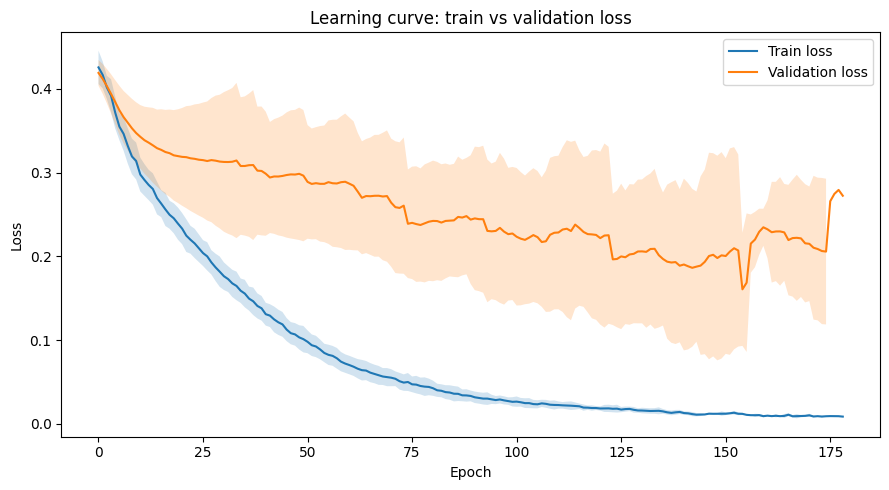

In [20]:
history_summary = (
    mlp_history_df
    .groupby("epoch")
    .agg(
        train_loss_mean=("train_loss", "mean"),
        train_loss_std=("train_loss", "std"),
        val_loss_mean=("val_loss", "mean"),
        val_loss_std=("val_loss", "std"),
    )
    .reset_index()
)

plt.figure(figsize=(9, 5))

plt.plot(
    history_summary["epoch"],
    history_summary["train_loss_mean"],
    label="Train loss",
)

plt.plot(
    history_summary["epoch"],
    history_summary["val_loss_mean"],
    label="Validation loss",
)

plt.fill_between(
    history_summary["epoch"],
    history_summary["train_loss_mean"] - history_summary["train_loss_std"],
    history_summary["train_loss_mean"] + history_summary["train_loss_std"],
    alpha=0.2,
)

plt.fill_between(
    history_summary["epoch"],
    history_summary["val_loss_mean"] - history_summary["val_loss_std"],
    history_summary["val_loss_mean"] + history_summary["val_loss_std"],
    alpha=0.2,
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning curve: train vs validation loss")
plt.legend()
plt.tight_layout()
plt.show()

### Gráfica de Accuracy promedio

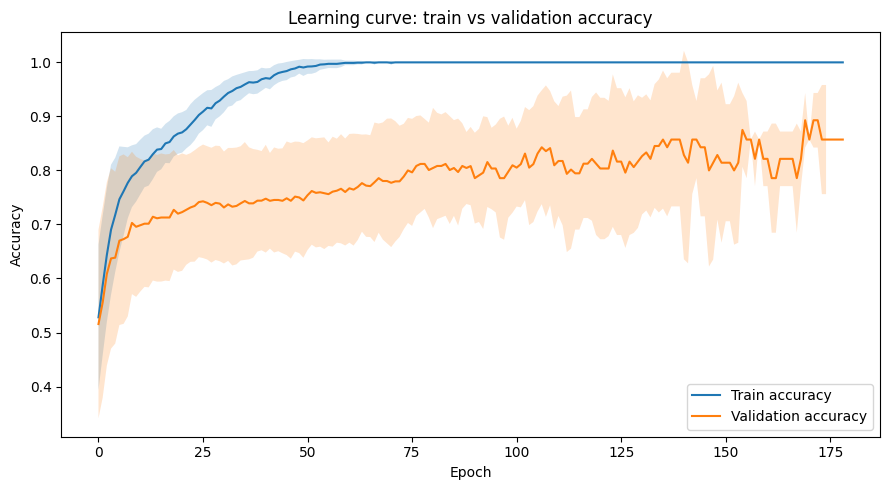

In [21]:
accuracy_summary = (
    mlp_history_df
    .groupby("epoch")
    .agg(
        train_accuracy_mean=("train_accuracy", "mean"),
        train_accuracy_std=("train_accuracy", "std"),
        val_accuracy_mean=("val_accuracy", "mean"),
        val_accuracy_std=("val_accuracy", "std"),
    )
    .reset_index()
)

plt.figure(figsize=(9, 5))

plt.plot(
    accuracy_summary["epoch"],
    accuracy_summary["train_accuracy_mean"],
    label="Train accuracy",
)

plt.plot(
    accuracy_summary["epoch"],
    accuracy_summary["val_accuracy_mean"],
    label="Validation accuracy",
)

plt.fill_between(
    accuracy_summary["epoch"],
    accuracy_summary["train_accuracy_mean"] - accuracy_summary["train_accuracy_std"],
    accuracy_summary["train_accuracy_mean"] + accuracy_summary["train_accuracy_std"],
    alpha=0.2,
)

plt.fill_between(
    accuracy_summary["epoch"],
    accuracy_summary["val_accuracy_mean"] - accuracy_summary["val_accuracy_std"],
    accuracy_summary["val_accuracy_mean"] + accuracy_summary["val_accuracy_std"],
    alpha=0.2,
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Learning curve: train vs validation accuracy")
plt.legend()
plt.tight_layout()
plt.show()

### Gráfica de Balanced Accuracy

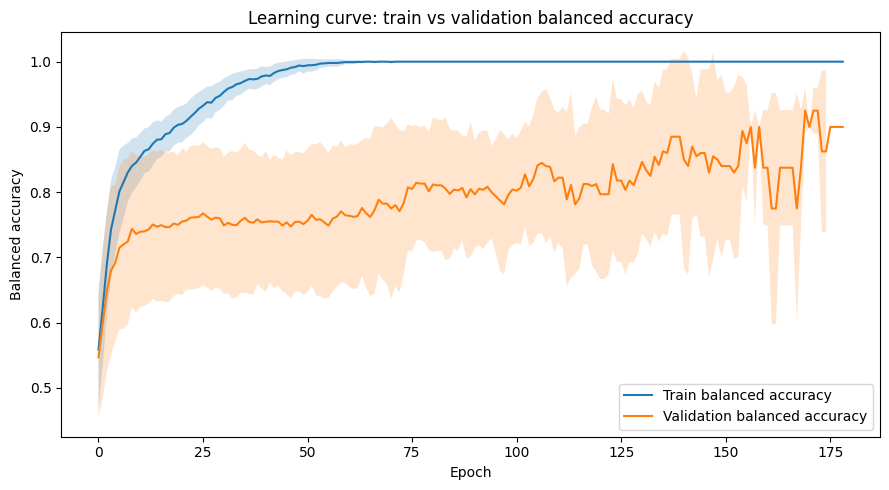

In [22]:
balanced_accuracy_summary = (
    mlp_history_df
    .groupby("epoch")
    .agg(
        train_balanced_accuracy_mean=("train_balanced_accuracy", "mean"),
        train_balanced_accuracy_std=("train_balanced_accuracy", "std"),
        val_balanced_accuracy_mean=("val_balanced_accuracy", "mean"),
        val_balanced_accuracy_std=("val_balanced_accuracy", "std"),
    )
    .reset_index()
)

plt.figure(figsize=(9, 5))

plt.plot(
    balanced_accuracy_summary["epoch"],
    balanced_accuracy_summary["train_balanced_accuracy_mean"],
    label="Train balanced accuracy",
)

plt.plot(
    balanced_accuracy_summary["epoch"],
    balanced_accuracy_summary["val_balanced_accuracy_mean"],
    label="Validation balanced accuracy",
)

plt.fill_between(
    balanced_accuracy_summary["epoch"],
    balanced_accuracy_summary["train_balanced_accuracy_mean"] - balanced_accuracy_summary["train_balanced_accuracy_std"],
    balanced_accuracy_summary["train_balanced_accuracy_mean"] + balanced_accuracy_summary["train_balanced_accuracy_std"],
    alpha=0.2,
)

plt.fill_between(
    balanced_accuracy_summary["epoch"],
    balanced_accuracy_summary["val_balanced_accuracy_mean"] - balanced_accuracy_summary["val_balanced_accuracy_std"],
    balanced_accuracy_summary["val_balanced_accuracy_mean"] + balanced_accuracy_summary["val_balanced_accuracy_std"],
    alpha=0.2,
)

plt.xlabel("Epoch")
plt.ylabel("Balanced accuracy")
plt.title("Learning curve: train vs validation balanced accuracy")
plt.legend()
plt.tight_layout()
plt.show()

### Gráfica de un fold individual

Seed: 0
Fold: 0


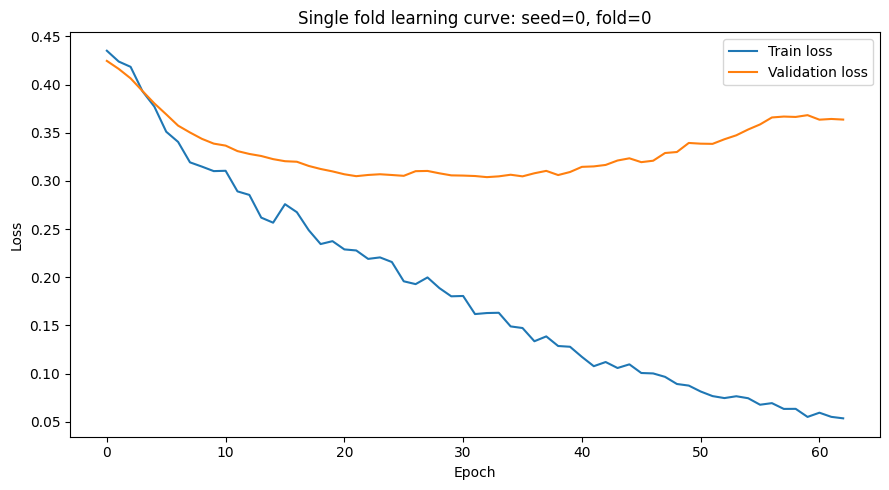

In [23]:
seed_to_plot = mlp_history_df["seed"].iloc[0]
fold_to_plot = mlp_history_df["fold"].iloc[0]

single_history = mlp_history_df[
    (mlp_history_df["seed"] == seed_to_plot)
    & (mlp_history_df["fold"] == fold_to_plot)
].copy()

print("Seed:", seed_to_plot)
print("Fold:", fold_to_plot)

plt.figure(figsize=(9, 5))

plt.plot(
    single_history["epoch"],
    single_history["train_loss"],
    label="Train loss",
)

plt.plot(
    single_history["epoch"],
    single_history["val_loss"],
    label="Validation loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Single fold learning curve: seed={seed_to_plot}, fold={fold_to_plot}")
plt.legend()
plt.tight_layout()
plt.show()

Y para accuracy:

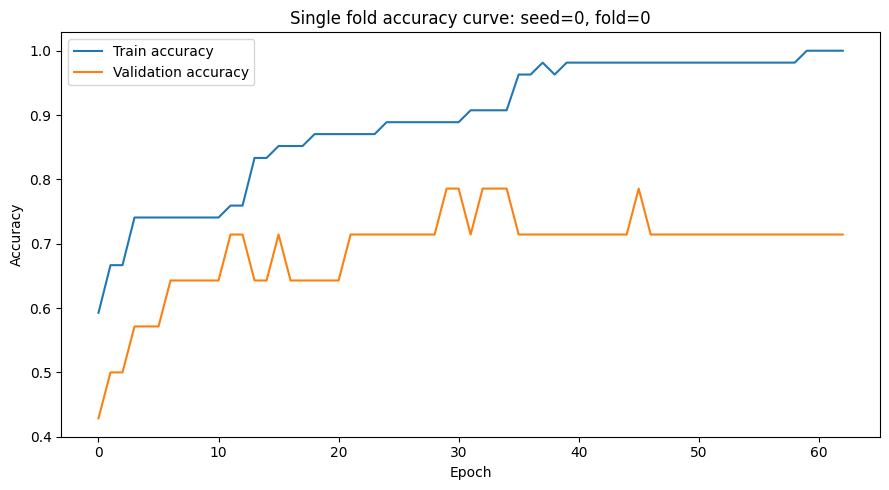

In [24]:
plt.figure(figsize=(9, 5))

plt.plot(
    single_history["epoch"],
    single_history["train_accuracy"],
    label="Train accuracy",
)

plt.plot(
    single_history["epoch"],
    single_history["val_accuracy"],
    label="Validation accuracy",
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"Single fold accuracy curve: seed={seed_to_plot}, fold={fold_to_plot}")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Resumen del MLP

In [25]:
mlp_summary_df = (
    mlp_results_df
    .groupby(["feature_set", "model"])
    .agg(
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        balanced_accuracy_std=("balanced_accuracy", "std"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),
        average_precision_mean=("average_precision", "mean"),
        average_precision_std=("average_precision", "std"),
        precision_mean=("precision", "mean"),
        precision_std=("precision", "std"),
        recall_mean=("recall", "mean"),
        recall_std=("recall", "std"),
    )
    .reset_index()
    .sort_values("roc_auc_mean", ascending=False)
)

display(mlp_summary_df.round(3))

,feature_set,model,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std,precision_mean,precision_std,recall_mean,recall_std
0,multimodal,pytorch_multimodal_mlp,0.728,0.083,0.767,0.086,0.811,0.091,0.912,0.054,0.88,0.082,0.698,0.133


Guardar los resultados

In [26]:
mlp_results_df.to_csv(
    RESULTS_DIR / "pytorch_multimodal_mlp_repeated_cv_all_folds.csv",
    index=False,
)

mlp_summary_df.to_csv(
    RESULTS_DIR / "pytorch_multimodal_mlp_repeated_cv_summary.csv",
    index=False,
)

mlp_history_df.to_csv(
    RESULTS_DIR / "pytorch_multimodal_mlp_training_history.csv",
    index=False,
)

print("Resultados guardados en:", RESULTS_DIR)

Resultados guardados en: /kaggle/working


## 10. Comparar contra el notebook 04

In [27]:
baseline_paths = [
    RESULTS_DIR / "model_results_repeated_cv_summary.csv",
    Path("../results/model_results_repeated_cv_summary.csv"),
    Path("/kaggle/working/model_results_repeated_cv_summary.csv"),
]

baseline_summary_df = None

for path in baseline_paths:
    if path.exists():
        baseline_summary_df = pd.read_csv(path)
        print("Baseline cargado desde:", path)
        break

if baseline_summary_df is None:
    print("No se encontró model_results_repeated_cv_summary.csv")
else:
    compare_df = pd.concat(
        [
            baseline_summary_df,
            mlp_summary_df,
        ],
        ignore_index=True,
    )

    compare_df = compare_df.sort_values(
        "roc_auc_mean",
        ascending=False,
    )

    display(
        compare_df[
            [
                "feature_set",
                "model",
                "balanced_accuracy_mean",
                "balanced_accuracy_std",
                "f1_mean",
                "roc_auc_mean",
                "roc_auc_std",
                "average_precision_mean",
                "precision_mean",
                "recall_mean",
            ]
        ].round(3)
    )

    compare_df.to_csv(
        RESULTS_DIR / "baseline_vs_pytorch_mlp_comparison.csv",
        index=False,
    )

Baseline cargado desde: /kaggle/working/model_results_repeated_cv_summary.csv


,feature_set,model,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,roc_auc_mean,roc_auc_std,average_precision_mean,precision_mean,recall_mean
0,multimodal,svm_rbf,0.779,0.108,0.850,0.879,0.080,0.946,0.882,0.833
1,multimodal,random_forest,0.727,0.115,0.842,0.860,0.093,0.938,0.837,0.860
2,video_only,svm_rbf,0.770,0.085,0.788,0.848,0.082,0.936,0.914,0.704
3,video_only,logistic_regression,0.763,0.092,0.791,0.846,0.082,0.937,0.910,0.712
4,clinical_only,random_forest,0.706,0.118,0.844,0.814,0.129,0.904,0.818,0.884
5,multimodal,logistic_regression,0.735,0.106,0.811,0.814,0.094,0.921,0.862,0.782
21,multimodal,pytorch_multimodal_mlp,0.728,0.083,0.767,0.811,0.091,0.912,0.880,0.698
6,video_only,random_forest,0.678,0.122,0.784,0.804,0.100,0.919,0.818,0.764
7,clinical_only,svm_rbf,0.740,0.113,0.836,0.800,0.145,0.891,0.851,0.836
8,clinical_only,logistic_regression,0.687,0.099,0.774,0.748,0.112,0.880,0.832,0.739
